In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [4]:
from src.preprocessing import FraudDetectionPipeline
import joblib


### Model Training with Target Encoded categorical data

2026-06-15 00:12:17,773 - INFO - Processed data loaded: (151112, 12)
2026-06-15 00:12:17,868 - INFO - Ran Feature Engineering.......
2026-06-15 00:12:18,092 - INFO - Computing transaction_frequency (train only)...
2026-06-15 00:12:18,456 - INFO - Applying Target Encoding to 'country'...
2026-06-15 00:12:18,741 - WARNING - Skipping scaling for zero-variance columns (will keep raw values): ['transaction_frequency']
2026-06-15 00:12:18,826 - INFO - Standard Scaling done....
2026-06-15 00:12:19,079 - INFO - One-Hot Encoding applied to 3 columns: ['source', 'browser', 'sex']
2026-06-15 00:12:19,089 - INFO - Categorical features detected → Using SMOTENC


Training shape before SMOTE: (120889, 18)
Training shape after  SMOTE: (164352, 18)


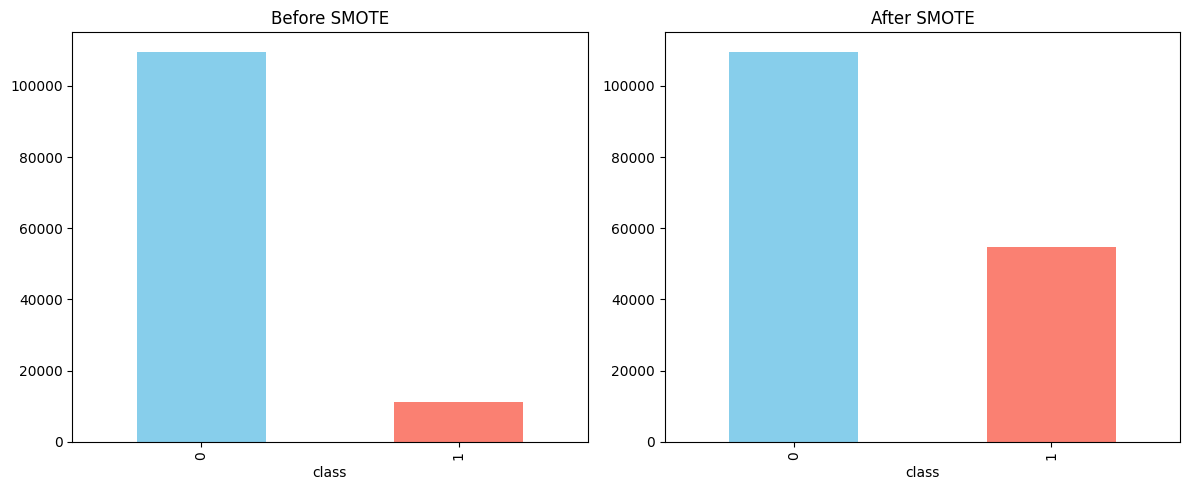

In [5]:
fraud_preprocessing=FraudDetectionPipeline('../data/processed/processedData.csv', is_fraud=True, country_encoding='target')
X_train, y_train, X_test, y_test=fraud_preprocessing.run()

In [6]:
from src.model_train import ModelTrain

2026-06-15 00:12:55,395 - INFO - Training Baseline Logistic Regression...


The AUC ROC score:  0.7501333618155008
The Average Precision Score:  0.39373737460683794
The F1 Score is  0.2821262932572244
THe True Negative: 18185 
 The False Postives: 9208 
 The False Negatives: 853 
 The true Positives: 1977
              precision    recall  f1-score   support

   Not Fraud       0.96      0.66      0.78     27393
       Fraud       0.18      0.70      0.28      2830

    accuracy                           0.67     30223
   macro avg       0.57      0.68      0.53     30223
weighted avg       0.88      0.67      0.74     30223



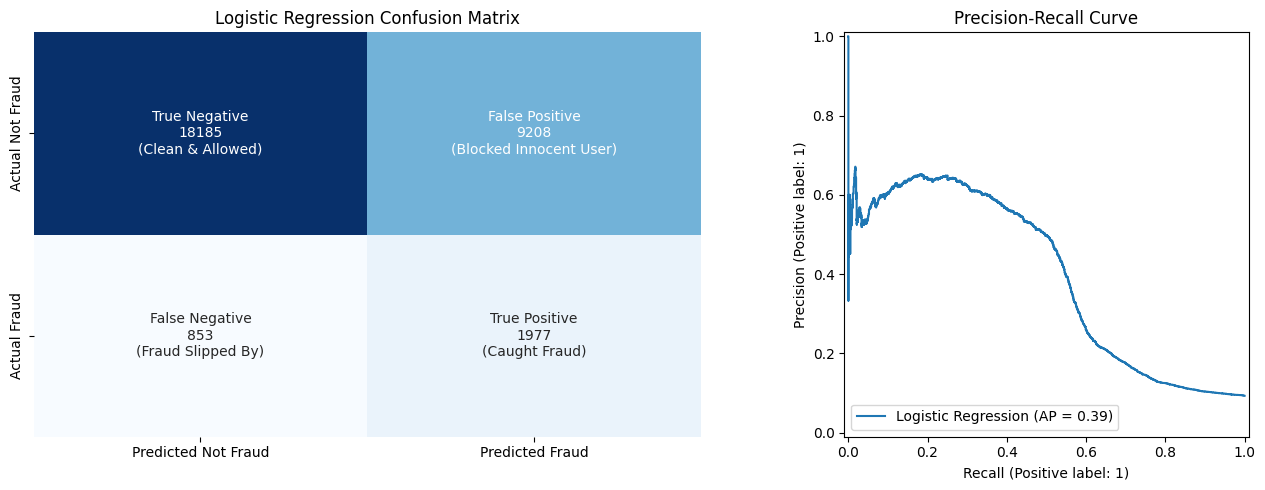

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [7]:
mt=ModelTrain(X_train, y_train, X_test, y_test)
mt.train_log_reg(n_iter=5000)

2026-06-15 00:12:57,664 - INFO - Starting Hyperparameter Tuning for Random_Forest...
2026-06-15 00:21:06,296 - INFO - Best parameters for Random_Forest: {'max_depth': 15, 'n_estimators': 300}



PERFORMANCE METRICS FOR: RANDOM_FOREST
The Average Precision Score:   0.6159
The F1 Score:                  0.6767
Recall (Fraud Class):          0.5244
THe True Negative (True Non-Frauds): 27321 
 The False Postives (Non-Frauds being passed as Frauds): 72 
 The False Negatives (Frauds being passed as Non-Fruads): 1346 
 The true Positives (True Fruads caught): 1484
              precision    recall  f1-score   support

   Not Fraud       0.95      1.00      0.97     27393
       Fraud       0.95      0.52      0.68      2830

    accuracy                           0.95     30223
   macro avg       0.95      0.76      0.83     30223
weighted avg       0.95      0.95      0.95     30223

--------------------------------------------------


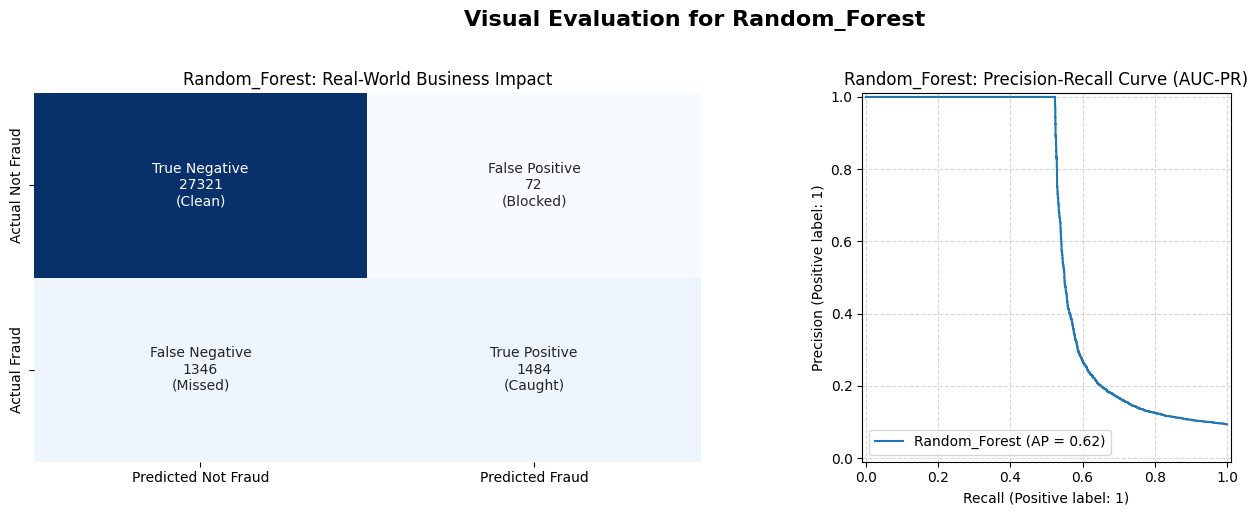

2026-06-15 00:21:11,365 - INFO - Starting Hyperparameter Tuning for XGBoost...
2026-06-15 00:22:25,693 - INFO - Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300}



PERFORMANCE METRICS FOR: XGBOOST
The Average Precision Score:   0.6087
The F1 Score:                  0.6721
Recall (Fraud Class):          0.5261
THe True Negative (True Non-Frauds): 27281 
 The False Postives (Non-Frauds being passed as Frauds): 112 
 The False Negatives (Frauds being passed as Non-Fruads): 1341 
 The true Positives (True Fruads caught): 1489
              precision    recall  f1-score   support

   Not Fraud       0.95      1.00      0.97     27393
       Fraud       0.93      0.53      0.67      2830

    accuracy                           0.95     30223
   macro avg       0.94      0.76      0.82     30223
weighted avg       0.95      0.95      0.95     30223

--------------------------------------------------


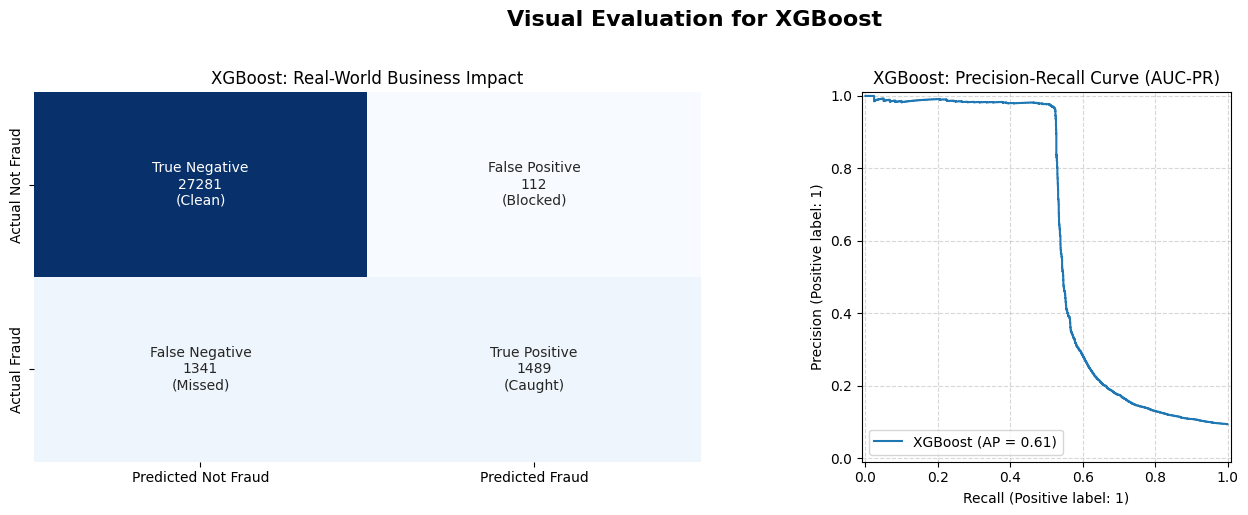

2026-06-15 00:22:27,323 - INFO - Starting Hyperparameter Tuning for LightGBM...
2026-06-15 00:23:29,857 - INFO - Best parameters for LightGBM: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300}



PERFORMANCE METRICS FOR: LIGHTGBM
The Average Precision Score:   0.6212
The F1 Score:                  0.6866
Recall (Fraud Class):          0.5233
THe True Negative (True Non-Frauds): 27390 
 The False Postives (Non-Frauds being passed as Frauds): 3 
 The False Negatives (Frauds being passed as Non-Fruads): 1349 
 The true Positives (True Fruads caught): 1481
              precision    recall  f1-score   support

   Not Fraud       0.95      1.00      0.98     27393
       Fraud       1.00      0.52      0.69      2830

    accuracy                           0.96     30223
   macro avg       0.98      0.76      0.83     30223
weighted avg       0.96      0.96      0.95     30223

--------------------------------------------------


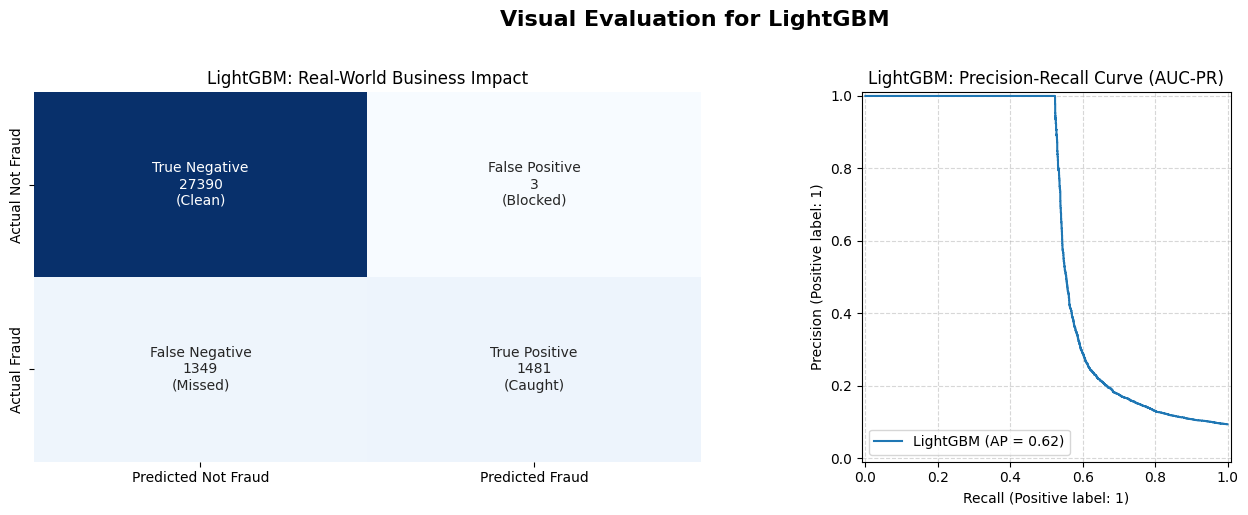

In [8]:
best_models=mt.train_and_evaluate_models()

In [9]:
mt.compare_all_models(best_models=best_models)

2026-06-15 00:23:33,704 - INFO - Running full CV comparison for Random_Forest...
2026-06-15 00:23:33,706 - INFO - Starting 5 metric Stratified K-Fold CV (k=5) for RandomForestClassifier...



MODEL COMPARISON: SIDE-BY-SIDE SUMMARY


2026-06-15 00:26:20,547 - INFO - Running full CV comparison for XGBoost...
2026-06-15 00:26:20,550 - INFO - Starting 5 metric Stratified K-Fold CV (k=5) for XGBClassifier...



CROSS-VALIDATION RESULTS for RandomForestClassifier
Average Precision        : 0.9463 ± 0.0017
Roc Auc                  : 0.9532 ± 0.0011
F1                       : 0.8509 ± 0.0036
Precision                : 0.9929 ± 0.0007
Recall                   : 0.7444 ± 0.0055

Per-fold scores:
Fold 1:
  Average Precision   : 0.9465
  Roc Auc             : 0.9533
  F1                  : 0.8566
  Precision           : 0.9934
  Recall              : 0.7529
Fold 2:
  Average Precision   : 0.9470
  Roc Auc             : 0.9535
  F1                  : 0.8524
  Precision           : 0.9926
  Recall              : 0.7469
Fold 3:
  Average Precision   : 0.9487
  Roc Auc             : 0.9549
  F1                  : 0.8508
  Precision           : 0.9921
  Recall              : 0.7447
Fold 4:
  Average Precision   : 0.9434
  Roc Auc             : 0.9516
  F1                  : 0.8486
  Precision           : 0.9941
  Recall              : 0.7403
Fold 5:
  Average Precision   : 0.9461
  Roc Auc             :

2026-06-15 00:26:44,281 - INFO - Running full CV comparison for LightGBM...
2026-06-15 00:26:44,284 - INFO - Starting 5 metric Stratified K-Fold CV (k=5) for LGBMClassifier...



CROSS-VALIDATION RESULTS for XGBClassifier
Average Precision        : 0.9578 ± 0.0012
Roc Auc                  : 0.9590 ± 0.0013
F1                       : 0.9320 ± 0.0019
Precision                : 0.9912 ± 0.0009
Recall                   : 0.8795 ± 0.0035

Per-fold scores:
Fold 1:
  Average Precision   : 0.9574
  Roc Auc             : 0.9592
  F1                  : 0.9303
  Precision           : 0.9912
  Recall              : 0.8764
Fold 2:
  Average Precision   : 0.9592
  Roc Auc             : 0.9605
  F1                  : 0.9333
  Precision           : 0.9899
  Recall              : 0.8829
Fold 3:
  Average Precision   : 0.9573
  Roc Auc             : 0.9586
  F1                  : 0.9339
  Precision           : 0.9910
  Recall              : 0.8831
Fold 4:
  Average Precision   : 0.9590
  Roc Auc             : 0.9599
  F1                  : 0.9332
  Precision           : 0.9926
  Recall              : 0.8805
Fold 5:
  Average Precision   : 0.9559
  Roc Auc             : 0.9568
 

{'Random_Forest': {'average_precision': np.float64(0.9463400030464483),
  'f1': np.float64(0.8508661637737044),
  'recall': np.float64(0.7443779265510105)},
 'XGBoost': {'average_precision': np.float64(0.9577785107823491),
  'f1': np.float64(0.9319744524448893),
  'recall': np.float64(0.8794539212880462)},
 'LightGBM': {'average_precision': np.float64(0.9585968726213364),
  'f1': np.float64(0.9461925576444443),
  'recall': np.float64(0.8979811985669495)}}

In [10]:
try:
    os.makedirs("../models/fraud/", exist_ok=True)
    for name, model in best_models.items(): joblib.dump(model, f"../models/fraud/{name}_final_model_target.pkl")
except:
    print('Error Saving the Model')
    raise 

### MOdel training with one hot encoded country

2026-06-15 00:27:01,295 - INFO - Processed data loaded: (151112, 12)
2026-06-15 00:27:01,396 - INFO - Ran Feature Engineering.......
2026-06-15 00:27:01,603 - INFO - Computing transaction_frequency (train only)...
2026-06-15 00:27:02,051 - INFO - Applying One-Hot Encoding to 'country'...
2026-06-15 00:27:02,068 - WARNING - Skipping scaling for zero-variance columns (will keep raw values): ['transaction_frequency']
2026-06-15 00:27:02,121 - INFO - Standard Scaling done....
2026-06-15 00:27:03,303 - INFO - One-Hot Encoding applied to 4 columns: ['source', 'browser', 'sex', 'country']
2026-06-15 00:27:03,341 - INFO - Categorical features detected → Using SMOTENC


Training shape before SMOTE: (120889, 196)
Training shape after  SMOTE: (164352, 196)


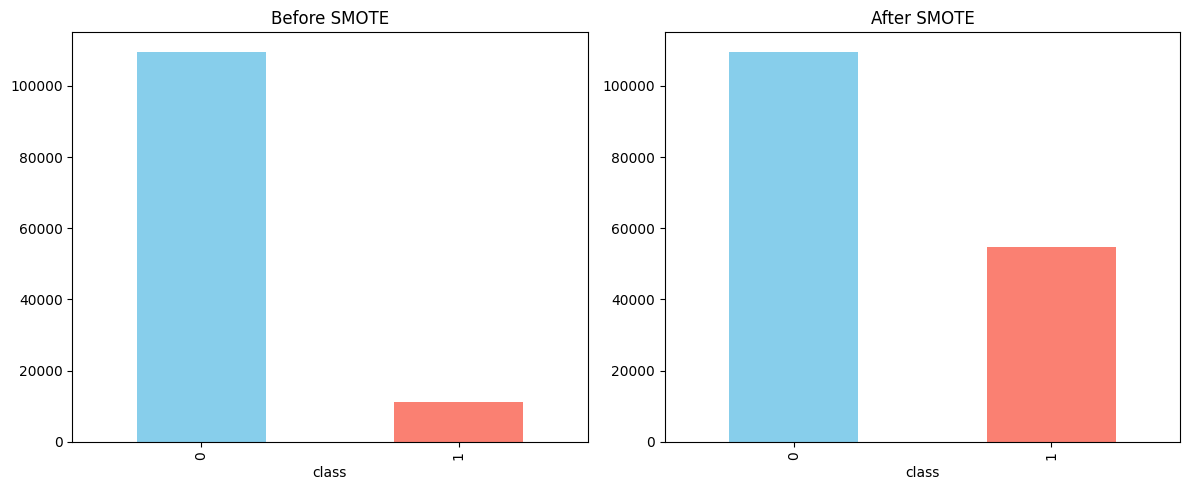

In [11]:
fraud_preprocessing_oh=FraudDetectionPipeline('../data/processed/processedData.csv', is_fraud=True, country_encoding='onehot')
X_train_c, y_train_c, X_test_c, y_test_c=fraud_preprocessing_oh.run()

2026-06-15 00:27:36,371 - INFO - Training Baseline Logistic Regression...


The AUC ROC score:  0.7477587771965678
The Average Precision Score:  0.3966464907931476
The F1 Score is  0.3292360921424019
THe True Negative: 21048 
 The False Postives: 6345 
 The False Negatives: 1022 
 The true Positives: 1808
              precision    recall  f1-score   support

   Not Fraud       0.95      0.77      0.85     27393
       Fraud       0.22      0.64      0.33      2830

    accuracy                           0.76     30223
   macro avg       0.59      0.70      0.59     30223
weighted avg       0.89      0.76      0.80     30223



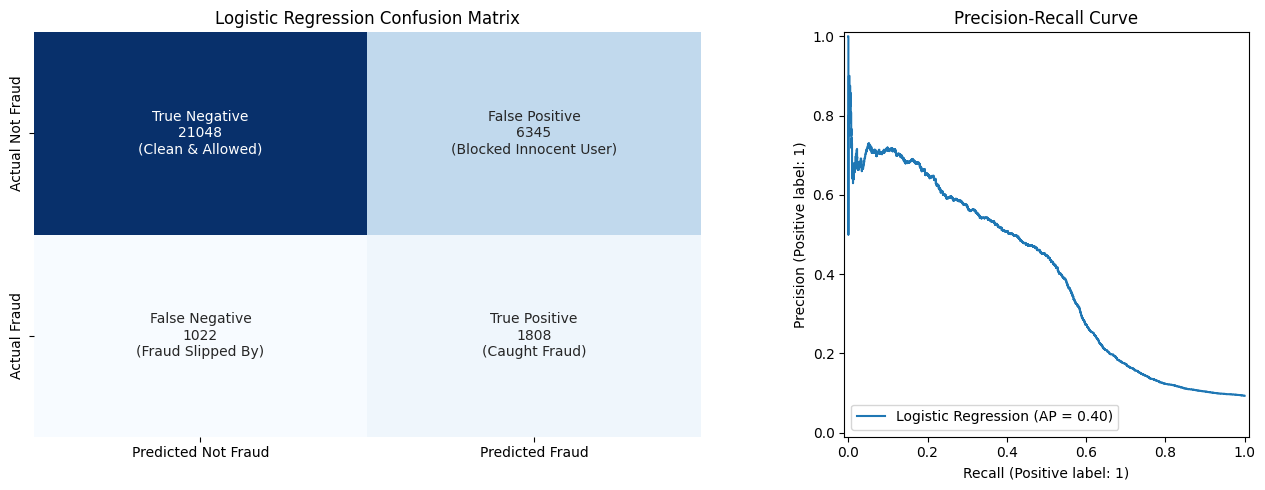

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [12]:
mt_oh=ModelTrain(X_train_c, y_train_c, X_test_c, y_test_c)
mt_oh.train_log_reg()

2026-06-15 00:27:48,259 - INFO - Starting Hyperparameter Tuning for Random_Forest...
2026-06-15 00:36:35,272 - INFO - Best parameters for Random_Forest: {'max_depth': 15, 'n_estimators': 200}



PERFORMANCE METRICS FOR: RANDOM_FOREST
The Average Precision Score:   0.6192
The F1 Score:                  0.6810
Recall (Fraud Class):          0.5244
THe True Negative (True Non-Frauds): 27349 
 The False Postives (Non-Frauds being passed as Frauds): 44 
 The False Negatives (Frauds being passed as Non-Fruads): 1346 
 The true Positives (True Fruads caught): 1484
              precision    recall  f1-score   support

   Not Fraud       0.95      1.00      0.98     27393
       Fraud       0.97      0.52      0.68      2830

    accuracy                           0.95     30223
   macro avg       0.96      0.76      0.83     30223
weighted avg       0.95      0.95      0.95     30223

--------------------------------------------------


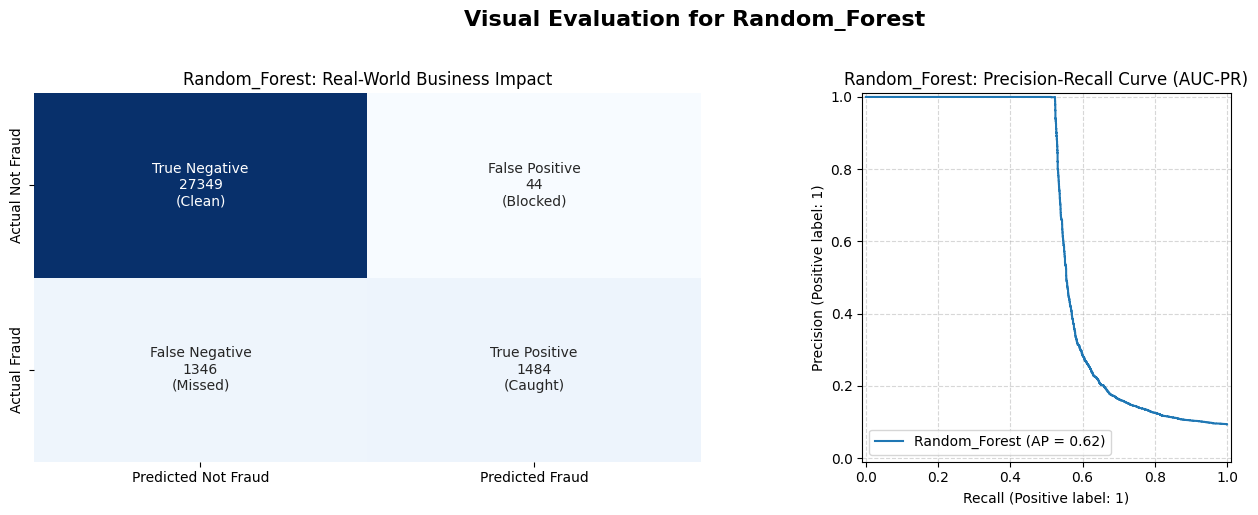

2026-06-15 00:36:39,952 - INFO - Starting Hyperparameter Tuning for XGBoost...
2026-06-15 00:43:11,942 - INFO - Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300}



PERFORMANCE METRICS FOR: XGBOOST
The Average Precision Score:   0.6069
The F1 Score:                  0.6756
Recall (Fraud Class):          0.5244
THe True Negative (True Non-Frauds): 27314 
 The False Postives (Non-Frauds being passed as Frauds): 79 
 The False Negatives (Frauds being passed as Non-Fruads): 1346 
 The true Positives (True Fruads caught): 1484
              precision    recall  f1-score   support

   Not Fraud       0.95      1.00      0.97     27393
       Fraud       0.95      0.52      0.68      2830

    accuracy                           0.95     30223
   macro avg       0.95      0.76      0.83     30223
weighted avg       0.95      0.95      0.95     30223

--------------------------------------------------


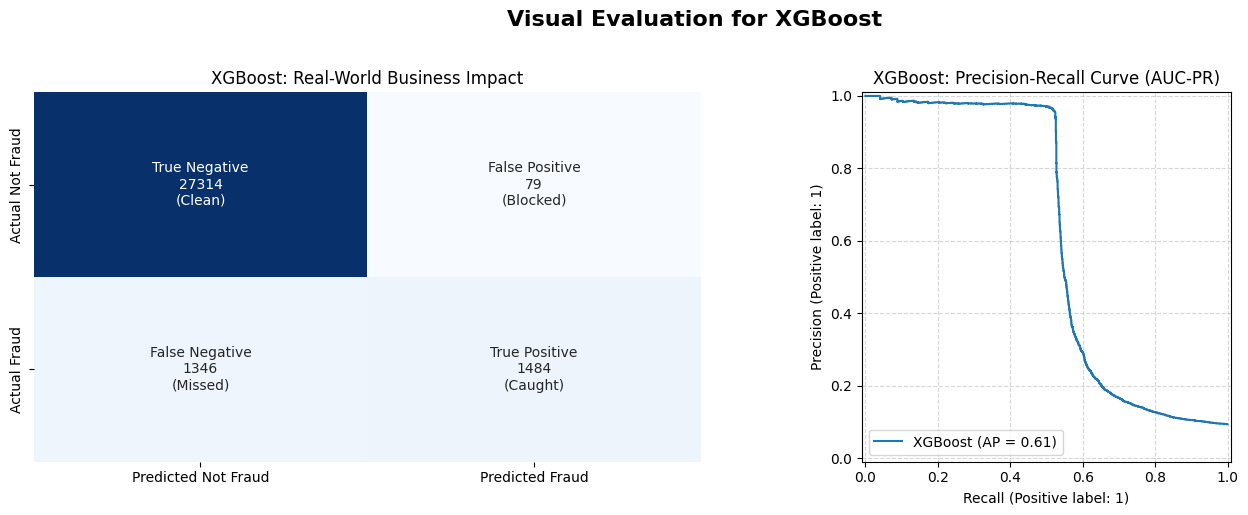

2026-06-15 00:43:15,138 - INFO - Starting Hyperparameter Tuning for LightGBM...
2026-06-15 00:45:28,935 - INFO - Best parameters for LightGBM: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300}



PERFORMANCE METRICS FOR: LIGHTGBM
The Average Precision Score:   0.6148
The F1 Score:                  0.6869
Recall (Fraud Class):          0.5233
THe True Negative (True Non-Frauds): 27392 
 The False Postives (Non-Frauds being passed as Frauds): 1 
 The False Negatives (Frauds being passed as Non-Fruads): 1349 
 The true Positives (True Fruads caught): 1481
              precision    recall  f1-score   support

   Not Fraud       0.95      1.00      0.98     27393
       Fraud       1.00      0.52      0.69      2830

    accuracy                           0.96     30223
   macro avg       0.98      0.76      0.83     30223
weighted avg       0.96      0.96      0.95     30223

--------------------------------------------------


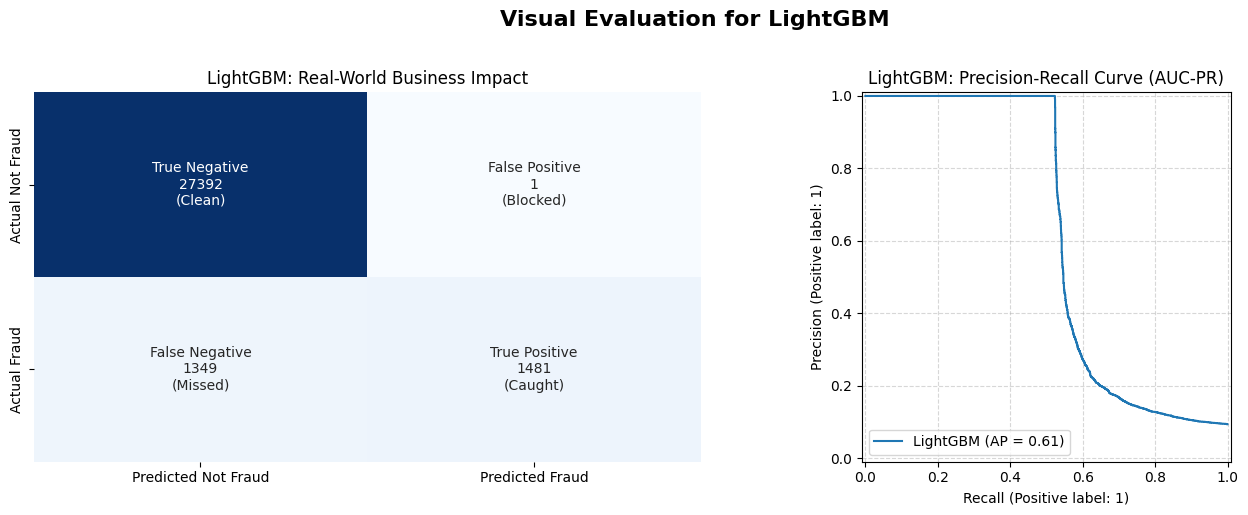

In [13]:
best_models_oh = mt_oh.train_and_evaluate_models()

In [14]:
mt_oh.compare_all_models(best_models=best_models_oh)

2026-06-15 00:45:34,853 - INFO - Running full CV comparison for Random_Forest...
2026-06-15 00:45:34,857 - INFO - Starting 5 metric Stratified K-Fold CV (k=5) for RandomForestClassifier...



MODEL COMPARISON: SIDE-BY-SIDE SUMMARY


2026-06-15 00:48:05,124 - INFO - Running full CV comparison for XGBoost...
2026-06-15 00:48:05,137 - INFO - Starting 5 metric Stratified K-Fold CV (k=5) for XGBClassifier...



CROSS-VALIDATION RESULTS for RandomForestClassifier
Average Precision        : 0.9317 ± 0.0025
Roc Auc                  : 0.9381 ± 0.0023
F1                       : 0.8278 ± 0.0039
Precision                : 0.9962 ± 0.0008
Recall                   : 0.7082 ± 0.0059

Per-fold scores:
Fold 1:
  Average Precision   : 0.9334
  Roc Auc             : 0.9390
  F1                  : 0.8285
  Precision           : 0.9948
  Recall              : 0.7099
Fold 2:
  Average Precision   : 0.9331
  Roc Auc             : 0.9396
  F1                  : 0.8337
  Precision           : 0.9962
  Recall              : 0.7168
Fold 3:
  Average Precision   : 0.9308
  Roc Auc             : 0.9371
  F1                  : 0.8283
  Precision           : 0.9959
  Recall              : 0.7089
Fold 4:
  Average Precision   : 0.9341
  Roc Auc             : 0.9406
  F1                  : 0.8273
  Precision           : 0.9972
  Recall              : 0.7069
Fold 5:
  Average Precision   : 0.9272
  Roc Auc             :

2026-06-15 00:49:30,472 - INFO - Running full CV comparison for LightGBM...
2026-06-15 00:49:30,475 - INFO - Starting 5 metric Stratified K-Fold CV (k=5) for LGBMClassifier...



CROSS-VALIDATION RESULTS for XGBClassifier
Average Precision        : 0.9561 ± 0.0013
Roc Auc                  : 0.9558 ± 0.0011
F1                       : 0.9392 ± 0.0038
Precision                : 0.9939 ± 0.0007
Recall                   : 0.8902 ± 0.0066

Per-fold scores:
Fold 1:
  Average Precision   : 0.9556
  Roc Auc             : 0.9551
  F1                  : 0.9407
  Precision           : 0.9930
  Recall              : 0.8936
Fold 2:
  Average Precision   : 0.9579
  Roc Auc             : 0.9574
  F1                  : 0.9431
  Precision           : 0.9937
  Recall              : 0.8974
Fold 3:
  Average Precision   : 0.9543
  Roc Auc             : 0.9545
  F1                  : 0.9320
  Precision           : 0.9933
  Recall              : 0.8779
Fold 4:
  Average Precision   : 0.9571
  Roc Auc             : 0.9569
  F1                  : 0.9407
  Precision           : 0.9947
  Recall              : 0.8923
Fold 5:
  Average Precision   : 0.9557
  Roc Auc             : 0.9552
 

{'Random_Forest': {'average_precision': np.float64(0.9316948370506186),
  'f1': np.float64(0.8278192590523015),
  'recall': np.float64(0.7081629812287223)},
 'XGBoost': {'average_precision': np.float64(0.9561222373489493),
  'f1': np.float64(0.939159419403621),
  'recall': np.float64(0.8901684379873489)},
 'LightGBM': {'average_precision': np.float64(0.9585776692784285),
  'f1': np.float64(0.9445035869285666),
  'recall': np.float64(0.8948963226190415)}}

### Fraud Detection Model Comparison Report

#### Executive Summary
This report compares four models trained on the **fraud_data** dataset using **Target Encoding** for the `country` feature: **Logistic Regression**, **Random Forest**, **XGBoost**, and **LightGBM**.

The dataset has a fraud rate of approximately **9.36%** (2,830 fraud cases out of 30,223 total samples). Primary evaluation metrics are **Average Precision (PR-AUC)** and **F1-score** (as requested), along with Precision, Recall, and confusion matrix components.

**LightGBM** remains the **clear recommended best model**. It achieves the highest Average Precision, strong F1-score, near-perfect precision, and extremely low false positives.

#### Key Performance Metrics Comparison (Test Set)

| Model                  | Avg Precision (PR-AUC) | F1-Score (Fraud) | Fraud Precision | Fraud Recall | True Positives | False Positives | False Negatives | Accuracy |
|------------------------|------------------------|------------------|-----------------|--------------|----------------|-----------------|-----------------|----------|
| **Logistic Regression**| 0.3937                 | 0.2821           | 0.18            | **0.70**     | 1977           | 9208            | 853             | 0.67     |
| **Random Forest**      | 0.6159                 | 0.6767           | 0.95            | 0.5244       | 1484           | 72              | 1346            | 0.95     |
| **XGBoost**            | 0.6087                 | 0.6721           | 0.93            | 0.5261       | 1489           | 112             | 1341            | 0.95     |
| **LightGBM**           | **0.6212**             | **0.6866**       | **1.00**        | 0.5233       | 1481           | **3**           | 1349            | **0.96** |

**Test Set Size**: 30,223 samples  
- **Not Fraud**: 27,393  
- **Fraud**: 2,830  

#### Detailed Model Analysis

 1. Logistic Regression
- **Strengths**: Highest fraud recall (0.70) — catches more actual fraud cases.
- **Weaknesses**: Very poor precision (0.18) and extremely low F1-score (0.28), resulting in **9,208 false positives**.
- **Business Impact**: Not suitable for production due to massive alert fatigue and customer dissatisfaction.

 2. Random Forest
- Solid Average Precision (0.6159) and good F1-score (0.6767).
- Low false positives (72) but still misses a large number of frauds (1,346).
- Reliable baseline but outperformed by gradient boosting models.

 3. XGBoost
- Competitive performance with good recall (0.5261).
- Slightly lower Average Precision and F1 compared to LightGBM.
- Acceptable false positives (112).

 4. LightGBM (Recommended)
- **Best overall model**.
- Highest **Average Precision (0.6212)** and highest **F1-score (0.6866)**.
- Exceptional precision of **1.00** with only **3 false positives**.
- Maintains reasonable recall (~52.3%) while keeping operational costs very low.

#### Precision-Recall Tradeoff Analysis
Fraud detection requires balancing:
- **High Recall** → Catch more fraud (but more false alarms).
- **High Precision** → Fewer false positives (better customer experience).

**LightGBM** offers the best tradeoff:
- Almost perfect precision (only **3 innocent transactions blocked**).
- Strong F1-score and top Average Precision.
- Significantly fewer false positives than XGBoost (112) and Random Forest (72).

### Business Justifications & Recommendations

**Why LightGBM with Target Encoding is the Best Choice:**

1. **Superior Primary Metrics**: Highest Avg Precision and F1-score on both test set and cross-validation.
2. **Minimal Operational Burden**: Only **3 false positives** dramatically lower review workload.
3. **High Confidence Alerts**: Precision of 1.00 means nearly every flagged case is truly fraudulent.
4. **Strong Generalization**: Excellent cross-validation scores (Avg Precision **0.9586**, F1 **0.9462**).
5. **Efficiency**: Fast training and inference, suitable for real-time fraud detection.

**Recommendation**:  
Deploy **LightGBM with Target Encoding** for `country`. Monitor performance in production and consider threshold tuning (e.g., 0.55–0.65) if you want to further reduce false positives or increase recall.


### Cross-Validation Results (5-fold Stratified)

**LightGBM**  
Average Precision : **0.9586 ± 0.0012**  
F1 : **0.9462 ± 0.0013**  
Recall : 0.8980 ± 0.0024  

**XGBoost**  
Average Precision : 0.9578 ± 0.0012  
F1 : 0.9320 ± 0.0019  

**Random Forest**  
Average Precision : 0.9463 ± 0.0017  
F1 : 0.8509 ± 0.0036  
